In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("/content/sales_data.csv")
df

,Order_ID,Category,Price,Quantity,Month,Revenue
0,1,Grocery,3863,3,Apr,11589
1,2,Electronics,1953,3,Apr,5859
2,3,Grocery,4759,4,Jan,19036
3,4,Grocery,1391,4,Feb,5564
4,5,Electronics,3681,4,Jan,14724
...,...,...,...,...,...,...
195,196,Clothing,104,1,Feb,104
196,197,Grocery,4969,2,Mar,9938
197,198,Grocery,976,1,Jan,976
198,199,Clothing,1091,1,Jan,1091


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Order_ID  200 non-null    int64 
 1   Category  200 non-null    object
 2   Price     200 non-null    int64 
 3   Quantity  200 non-null    int64 
 4   Month     200 non-null    object
 5   Revenue   200 non-null    int64 
dtypes: int64(4), object(2)
memory usage: 9.5+ KB


In [8]:
df.describe()

,Order_ID,Price,Quantity,Revenue
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,2649.465000,2.425000,6586.855000
std,57.879185,1399.779135,1.166697,5034.849046
min,1.000000,104.000000,1.000000,104.000000
25%,50.750000,1379.000000,1.000000,2540.250000
50%,100.500000,2834.000000,2.000000,4948.000000
75%,150.250000,3826.250000,4.000000,9649.500000
max,200.000000,4993.000000,4.000000,19972.000000


In [9]:
df["Category"].value_counts()

,count
Category,
Grocery,73
Electronics,66
Clothing,61


In [10]:
# Data Cleaning
df.isnull().sum()

,0
Order_ID,0
Category,0
Price,0
Quantity,0
Month,0
Revenue,0


In [11]:
df.fillna(0, inplace=True)

In [12]:
#Total Revenue by Category
category_sale = df.groupby("Category")['Revenue'].sum()

In [13]:
# Identify the revenue trends
monthly_sales = df.groupby("Month")['Revenue'].sum()

In [14]:
# Average order value
avg_order = df["Revenue"].mean()

In [15]:
#Max, Min and average Revenue
revenue_array = df["Revenue"].values
print(np.max(revenue_array))
print(np.min(revenue_array ))
print(np.mean(revenue_array))

19972
104
6586.855


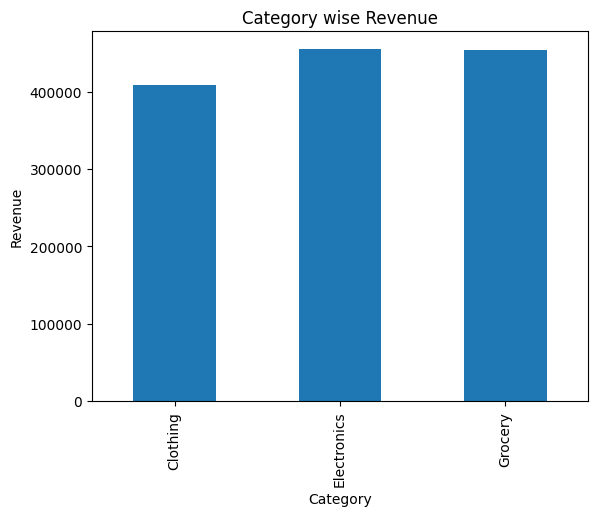

In [16]:
# Plot category wise REvenue

category_sale.plot(kind='bar')
plt.title("Category wise Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

Text(0, 0.5, 'Revenue')

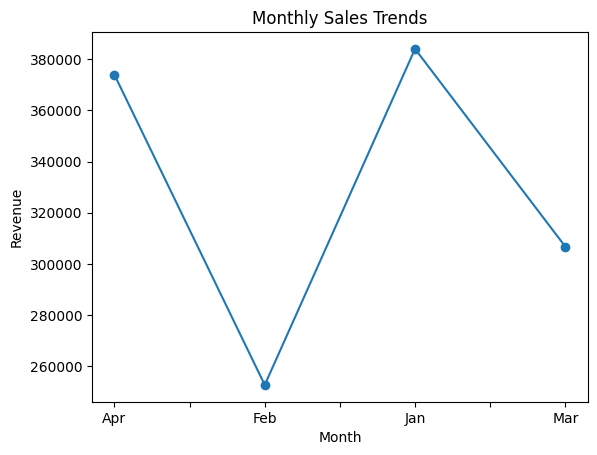

In [17]:
from matplotlib import markers
# Identify the monthly sales trends
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trends")
plt.xlabel("Month")
plt.ylabel("Revenue")

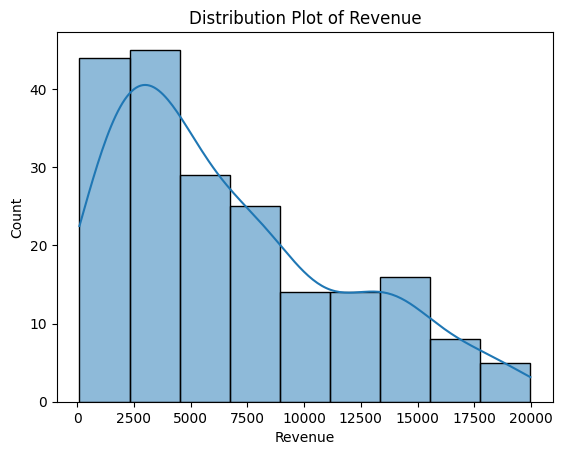

In [18]:
#Distribution Plot
sns.histplot(df["Revenue"], kde=True)
plt.title("Distribution Plot of Revenue")
plt.show()

Text(0.5, 1.0, 'Revenue by Category')

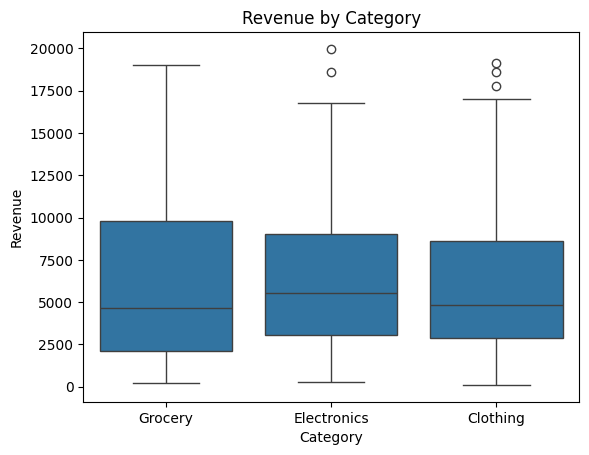

In [19]:
# Box Plot
sns.boxplot(x="Category", y="Revenue", data=df)
plt.title("Revenue by Category")


<Axes: xlabel='Quantity', ylabel='Revenue'>

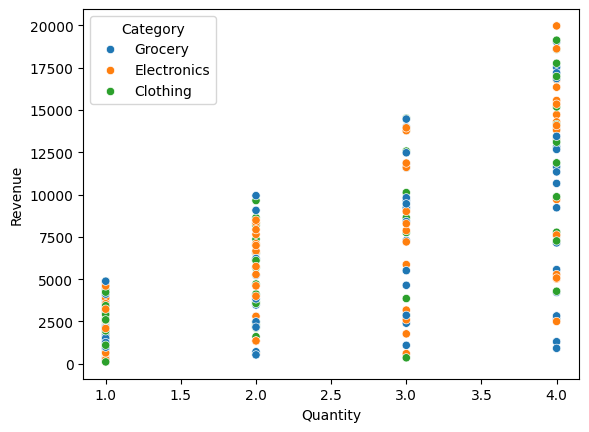

In [20]:
# Scatter plot
sns.scatterplot(x="Quantity", y="Revenue", hue="Category", data=df)

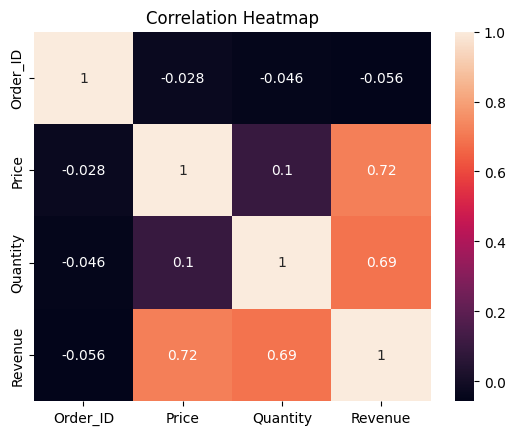

In [21]:
#Heatmap
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()



In [22]:
df.to_csv("salesupdated.csv", index=False)

Ex 2

In [23]:
df = pd.read_csv("/content/weather_data.csv")
df

,date,temperature,windspeed,humidity,event
0,2024-01-01,32,6,80,Rain
1,2024-01-02,35,7,70,Sunny
2,2024-01-03,28,2,90,Snow
3,2024-01-04,24,7,85,Snow
4,2024-01-05,32,4,75,Rain
5,2024-01-06,31,2,60,Sunny
6,2024-01-07,30,5,65,Cloudy
7,2024-01-08,29,3,88,Rain


In [24]:
#Basic understanding
df.head()


,date,temperature,windspeed,humidity,event
0,2024-01-01,32,6,80,Rain
1,2024-01-02,35,7,70,Sunny
2,2024-01-03,28,2,90,Snow
3,2024-01-04,24,7,85,Snow
4,2024-01-05,32,4,75,Rain


In [25]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         8 non-null      object
 1   temperature  8 non-null      int64 
 2   windspeed    8 non-null      int64 
 3   humidity     8 non-null      int64 
 4   event        8 non-null      object
dtypes: int64(3), object(2)
memory usage: 452.0+ bytes


In [26]:
df.shape


(8, 5)

In [27]:
df.describe()

,temperature,windspeed,humidity
count,8.000000,8.000000,8.00000
mean,30.125000,4.500000,76.62500
std,3.270539,2.070197,11.00568
min,24.000000,2.000000,60.00000
25%,28.750000,2.750000,68.75000
50%,30.500000,4.500000,77.50000
75%,32.000000,6.250000,85.75000
max,35.000000,7.000000,90.00000


In [28]:
#Temperature Analysis
print(df["temperature"].mean()) # Average temperature

30.125


In [29]:
print(df["temperature"].min()) # Minimum Temperature

24


In [30]:
print(df["temperature"].max()) # Maximum Temperature

35


In [31]:
# Wind speed Analysis
print(df["windspeed"].mean())

4.5


In [32]:
#Days with high speed(>5)
df[df["windspeed"] > 5]

,date,temperature,windspeed,humidity,event
0,2024-01-01,32,6,80,Rain
1,2024-01-02,35,7,70,Sunny
3,2024-01-04,24,7,85,Snow


In [33]:
#Humidity Analysis
print(df["humidity"].mean())

76.625


In [34]:
# High humidity days (> 80)
df[df["humidity"] > 80]

,date,temperature,windspeed,humidity,event
2,2024-01-03,28,2,90,Snow
3,2024-01-04,24,7,85,Snow
7,2024-01-08,29,3,88,Rain


In [35]:
# count event
df["event"].value_counts()

,count
event,
Rain,3
Sunny,2
Snow,2
Cloudy,1


In [36]:
# Identify Rain days
df[df["event"] == "Rain"]

,date,temperature,windspeed,humidity,event
0,2024-01-01,32,6,80,Rain
4,2024-01-05,32,4,75,Rain
7,2024-01-08,29,3,88,Rain


In [37]:
#Data Preprocessing
#convert date into datetime
df["date"] = pd.to_datetime(df["date"])

In [38]:
# Extract day and month
df["day"] = df["date"].dt.day

In [39]:
df["month"] = df["date"].dt.month

In [40]:
df

,date,temperature,windspeed,humidity,event,day,month
0,2024-01-01,32,6,80,Rain,1,1
1,2024-01-02,35,7,70,Sunny,2,1
2,2024-01-03,28,2,90,Snow,3,1
3,2024-01-04,24,7,85,Snow,4,1
4,2024-01-05,32,4,75,Rain,5,1
5,2024-01-06,31,2,60,Sunny,6,1
6,2024-01-07,30,5,65,Cloudy,7,1
7,2024-01-08,29,3,88,Rain,8,1


In [41]:
# Temperature in Fahreneit
df["tempf"] = (df["temperature"] * 9/5) + 32

In [42]:
df


,date,temperature,windspeed,humidity,event,day,month,tempf
0,2024-01-01,32,6,80,Rain,1,1,89.6
1,2024-01-02,35,7,70,Sunny,2,1,95.0
2,2024-01-03,28,2,90,Snow,3,1,82.4
3,2024-01-04,24,7,85,Snow,4,1,75.2
4,2024-01-05,32,4,75,Rain,5,1,89.6
5,2024-01-06,31,2,60,Sunny,6,1,87.8
6,2024-01-07,30,5,65,Cloudy,7,1,86.0
7,2024-01-08,29,3,88,Rain,8,1,84.2


In [43]:
#Average temperature according to event
df.groupby("event")["temperature"].mean()

,temperature
event,
Cloudy,30.0
Rain,31.0
Snow,26.0
Sunny,33.0


In [44]:
#Max humidity as per the event
df.groupby("event")["humidity"].max()

,humidity
event,
Cloudy,65
Rain,88
Snow,90
Sunny,70


In [45]:
#Sunny days having temperature > 30
df[(df["event"] == "Sunny") & (df["temperature"] > 30)]

,date,temperature,windspeed,humidity,event,day,month,tempf
1,2024-01-02,35,7,70,Sunny,2,1,95.0
5,2024-01-06,31,2,60,Sunny,6,1,87.8


In [46]:
# sort according to the temperature
df.sort_values("temperature", ascending=False)

,date,temperature,windspeed,humidity,event,day,month,tempf
1,2024-01-02,35,7,70,Sunny,2,1,95.0
0,2024-01-01,32,6,80,Rain,1,1,89.6
4,2024-01-05,32,4,75,Rain,5,1,89.6
5,2024-01-06,31,2,60,Sunny,6,1,87.8
6,2024-01-07,30,5,65,Cloudy,7,1,86.0
7,2024-01-08,29,3,88,Rain,8,1,84.2
2,2024-01-03,28,2,90,Snow,3,1,82.4
3,2024-01-04,24,7,85,Snow,4,1,75.2


Ex 3

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

<Axes: xlabel='event', ylabel='temperature'>

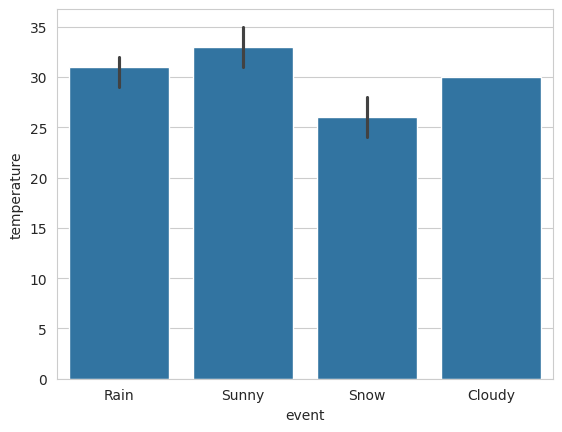

In [48]:
sns.barplot(x="event", y="temperature", data=df)

<Axes: xlabel='event', ylabel='temperature'>

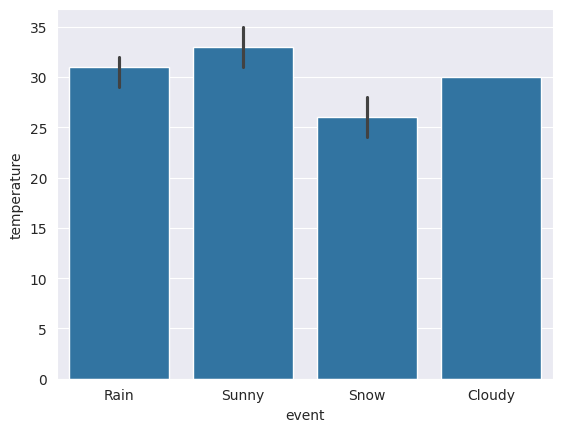

In [49]:
sns.set_style("darkgrid")
sns.barplot(x="event", y="temperature", data=df)

<Axes: xlabel='event', ylabel='temperature'>

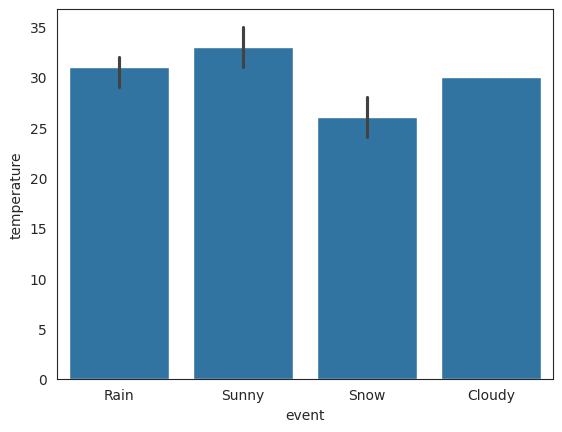

In [50]:
sns.set_style("white")
sns.barplot(x="event", y="temperature", data=df)

<Axes: xlabel='event', ylabel='temperature'>

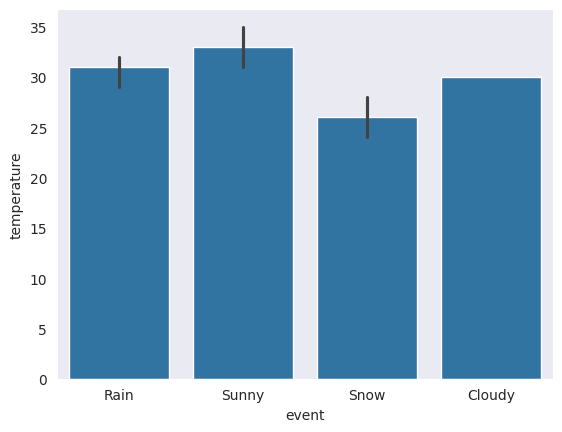

In [51]:
sns.set_style("dark")
sns.barplot(x="event", y="temperature", data=df)

In [52]:
data = {
    "date": ["2024-01-01","2024-01-02","2024-01-03","2024-01-04",
             "2024-01-05","2024-01-06","2024-01-07","2024-01-08"],
    "temperature": [32,35,28,24,32,31,30,29],
    "windspeed": [6,7,2,7,4,2,5,3],
    "humidity": [80,70,90,85,75,60,65,88],
    "event": ["Rain","Sunny","Snow","Snow","Rain","Sunny","Cloudy","Rain"]
}

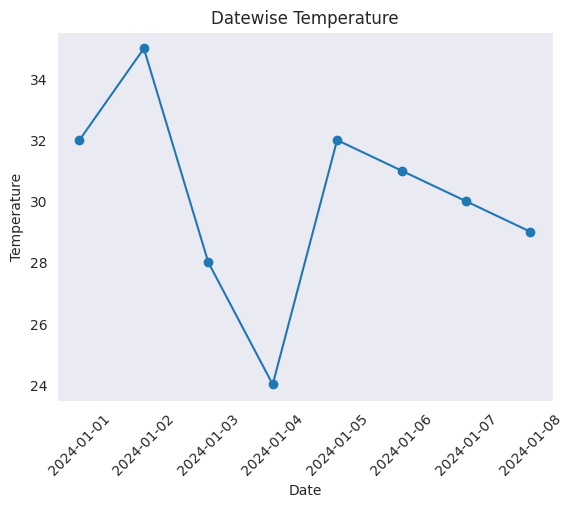

In [53]:
#Visualize datewise temperature
plt.plot(df["date"], df["temperature"], marker="o")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.title("Datewise Temperature")
plt.xticks(rotation=45)
plt.show()

Ex

In [54]:
 data = {
    "Name": ["A", "B", "C", "D"],
    "Age": [25, np.nan, 30, np.nan],
    "Marks": [80, 90, np.nan, 85]
}
data

{'Name': ['A', 'B', 'C', 'D'],
 'Age': [25, nan, 30, nan],
 'Marks': [80, 90, nan, 85]}

In [55]:
df = pd.DataFrame(data)
df

,Name,Age,Marks
0,A,25.0,80.0
1,B,NaN,90.0
2,C,30.0,NaN
3,D,NaN,85.0


In [56]:
df1 = df.dropna()
df1

,Name,Age,Marks
0,A,25.0,80.0


In [57]:
df1

,Name,Age,Marks
0,A,25.0,80.0


In [58]:
# Mean Imputation
df["Age"].fillna(df["Age"].mean(), inplace=True)
df["Marks"].fillna(df["Marks"].mean(), inplace=True)
df

/tmp/ipykernel_11408/4199710948.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(), inplace=True)
/tmp/ipykernel_11408/4199710948.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

,Name,Age,Marks
0,A,25.0,80.0
1,B,27.5,90.0
2,C,30.0,85.0
3,D,27.5,85.0


In [59]:
df = pd.DataFrame(data)
df

,Name,Age,Marks
0,A,25.0,80.0
1,B,NaN,90.0
2,C,30.0,NaN
3,D,NaN,85.0


In [60]:
df["Age"].fillna(df["Age"].median(), inplace=True)
df["Marks"].fillna(df["Marks"].median(), inplace=True)
df

/tmp/ipykernel_11408/2730704133.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
/tmp/ipykernel_11408/2730704133.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

,Name,Age,Marks
0,A,25.0,80.0
1,B,27.5,90.0
2,C,30.0,85.0
3,D,27.5,85.0


In [61]:
# Mode Imputation
data = {
        "City": ["Mumbai", "Delhi", np.nan, "Mumbai", np.nan]
    }
df = pd.DataFrame(data)
df


,City
0,Mumbai
1,Delhi
2,NaN
3,Mumbai
4,NaN


In [62]:
df["City"].fillna(df["City"].mode()[0], inplace=True)
df

/tmp/ipykernel_11408/4020894660.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["City"].fillna(df["City"].mode()[0], inplace=True)


,City
0,Mumbai
1,Delhi
2,Mumbai
3,Mumbai
4,Mumbai


In [63]:

#fill forward
data = {
    "Time": ["T1", "T2", "T3", "T4"],
    "Temp": [30, np.nan, np.nan, 35]
}

df = pd.DataFrame(data)
df

,Time,Temp
0,T1,30.0
1,T2,NaN
2,T3,NaN
3,T4,35.0


In [64]:
df["Temp"].fillna(method='ffill', inplace=True)
df

/tmp/ipykernel_11408/842029225.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Temp"].fillna(method='ffill', inplace=True)
/tmp/ipykernel_11408/842029225.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["Temp"].fillna(method='ffill', inplace=True)


,Time,Temp
0,T1,30.0
1,T2,30.0
2,T3,30.0
3,T4,35.0


In [65]:
#Fill backward
data = {
    "Time": ["T1", "T2", "T3", "T4"],
    "Temp": [30, np.nan, np.nan, 35]
}

df = pd.DataFrame(data)
df

,Time,Temp
0,T1,30.0
1,T2,NaN
2,T3,NaN
3,T4,35.0


In [66]:
df["Temp"].fillna(method='bfill', inplace=True)
df

/tmp/ipykernel_11408/3734849696.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Temp"].fillna(method='bfill', inplace=True)
/tmp/ipykernel_11408/3734849696.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["Temp"].fillna(method='bfill', inplace=True)


,Time,Temp
0,T1,30.0
1,T2,35.0
2,T3,35.0
3,T4,35.0


In [67]:
# Interpolation
data = {
    "Time": ["T1", "T2", "T3", "T4"],
    "Temp": [30, np.nan, np.nan, 35]
}

df = pd.DataFrame(data)
df

,Time,Temp
0,T1,30.0
1,T2,NaN
2,T3,NaN
3,T4,35.0


In [68]:
df["Temp"] = df["Temp"].interpolate()
df

,Time,Temp
0,T1,30.000000
1,T2,31.666667
2,T3,33.333333
3,T4,35.000000


In [69]:
# Constant Value Imputation
data = {
    "Name": ["A", "B", np.nan, "D"],
    "Age": [25, np.nan, 30, np.nan],
    "Marks": [80, 90, np.nan, 85]
}

df = pd.DataFrame(data)
df

,Name,Age,Marks
0,A,25.0,80.0
1,B,NaN,90.0
2,NaN,30.0,NaN
3,D,NaN,85.0


In [70]:
df["Marks"].fillna(80, inplace=True)
df["Age"].fillna(25, inplace=True)
df["Name"].fillna("Unknown", inplace=True)
df

/tmp/ipykernel_11408/2558634508.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Marks"].fillna(80, inplace=True)
/tmp/ipykernel_11408/2558634508.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.

,Name,Age,Marks
0,A,25.0,80.0
1,B,25.0,90.0
2,Unknown,30.0,80.0
3,D,25.0,85.0
